In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Наложение и удаление шума

In [2]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

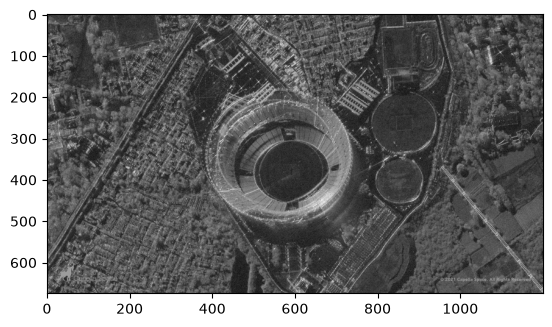

In [3]:
plt.imshow(image_gray, cmap="gray")

In [4]:
# Gaussian noise
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,  16,   0, ..., 111,   0,  80],
       [  1, 104,  68, ...,   0, 103,   0],
       [  0,   0,  51, ...,   0,   0, 145],
       ...,
       [  0,   0,  39, ..., 255,   0,  15],
       [  0,  34,   0, ...,   0,   5, 135],
       [160, 204,   0, ...,  21,   0, 109]],
      shape=(675, 1200), dtype=uint8)

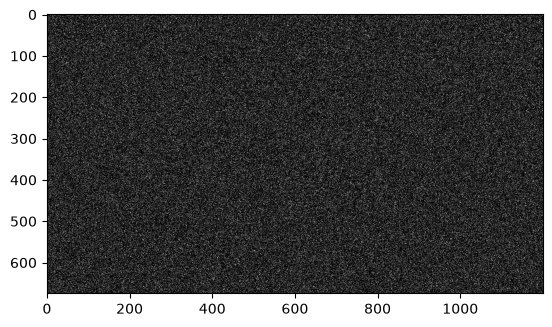

In [5]:
plt.imshow(noise_gauss, cmap="gray")

In [6]:
# Salt and pepper
noise =  np.random.randint(0, 101, size = (image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

In [7]:
bg_image = np.ones(image_gray.shape, np.uint8) * 128

In [8]:
bg_image[zeros_pixel] = 0
bg_image[ones_pixel] = 255

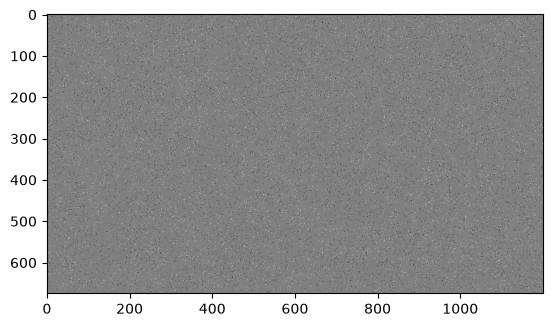

In [9]:
plt.imshow(bg_image, cmap="gray")

In [10]:
image_noise_gauss = cv2.add(image_gray,noise_gauss)

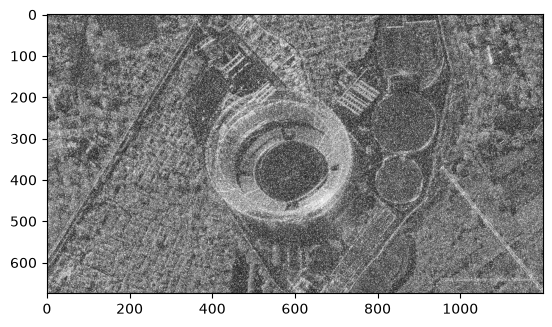

In [11]:
plt.imshow(image_noise_gauss, cmap="gray")

In [12]:
from skimage.metrics import structural_similarity, mean_squared_error
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print(mse_gauss, ssim)

4230.673058024691 0.18699266800035377


In [13]:
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)

In [14]:
mse_gauss_median = mean_squared_error(image_gray, image_gauss_median)
(ssim_gauss_median, diff) = structural_similarity(image_gray,  image_gauss_median, full=True)

In [15]:
print(mse_gauss_median, ssim_gauss_median)

1038.0453432098766 0.42824305715634176


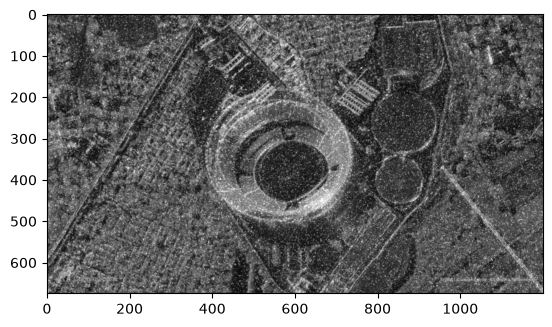

In [16]:
plt.imshow(image_gauss_median, cmap="gray")

In [17]:
import copy

image_sp = copy.deepcopy(image_gray)

image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

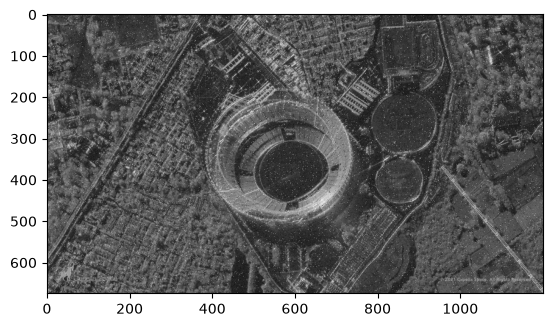

In [18]:
plt.imshow(image_sp, cmap="gray")

In [19]:
mse_sp = mean_squared_error(image_gray, image_sp)
(ssim_sp, diff) = structural_similarity(image_gray, image_sp, full=True)
print(mse_sp, ssim_sp)

390.00085925925924 0.7211595279245117


In [20]:
image_sp_median = cv2.medianBlur(image_sp, 3)

In [21]:
mse_sp_median = mean_squared_error(image_gray, image_sp_median)
(ssim_sp_median, diff) = structural_similarity(image_gray, image_sp_median, full=True)
print(mse_sp_median, ssim_sp_median)

95.71412345679012 0.8162268085060994


# Другие типы фильтров

In [22]:
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(5,5),0)

In [23]:
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,9,75,75)

In [24]:
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)

In [25]:
import math

def geom(a):
    prod = 1
    for i in range(a.shape[0]):
        prod1 = 1
        for j in range(a.shape[1]):
            prod1 *= a[i,j]
        prod1 = math.pow(prod1, 1.0/9.0)
        prod *= prod1
    return prod

def proc(img, filter):
    img_res = copy.deepcopy(img)
    for i in range(0,img.shape[0] -2):
        for j in range(0,img.shape[1] -2):
            img_res[i:i+3, j:j+3] = filter(img[i:i+3, j:j+3])
    return img_res
    
res = proc(image_noise_gauss, geom)


C:\Users\L3and1r\AppData\Local\Temp\ipykernel_8380\164976186.py:8: RuntimeWarning: overflow encountered in scalar multiply
  prod1 *= a[i,j]


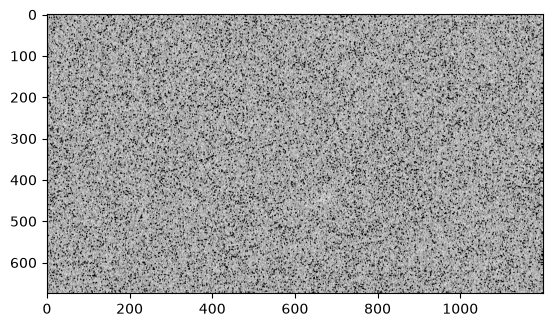

In [26]:
plt.imshow(res, cmap="gray")

In [27]:
mse_geom = mean_squared_error(image_gray, res)
(ssim_geom, diff) = structural_similarity(image_gray, res, full=True)
print(mse_geom, ssim_geom)

6551.976648148148 0.02746126776511089



# 2D свертка

In [28]:
# averaging filter
kernel_5 = np.ones((5,5),np.float32)/25
image_k5 = cv2.filter2D(image_gray,-1,kernel_5)
# blured_image = cv2.blur(img,(5,5))
image_b5 = cv2.blur(image_gray,(5,5))

In [29]:
mse_kb = mean_squared_error(image_k5, image_b5)
(ssim_kb, diff) = structural_similarity(image_k5, image_b5, full=True)
print(mse_kb, ssim_kb)

0.0 1.0


In [30]:
# Laplasian
kernel_lapl = np.array([[0,-10,0],
                        [-10,40,-10],
                        [0,-10,0]], np.float32)

In [31]:
image_lapl = cv2.filter2D(image_gray,-1,kernel_lapl) 

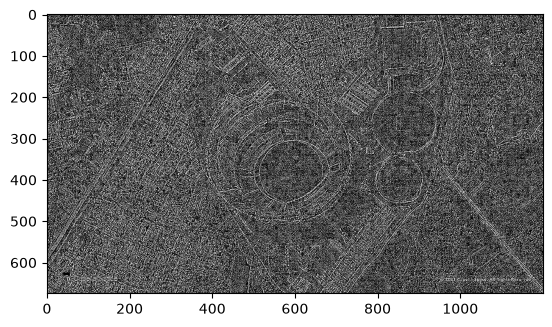

In [32]:
plt.imshow(image_lapl, cmap="gray")

In [33]:
# ДЗ 2
# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.

# ДЗ 2

Размер изображения: (675, 1200)


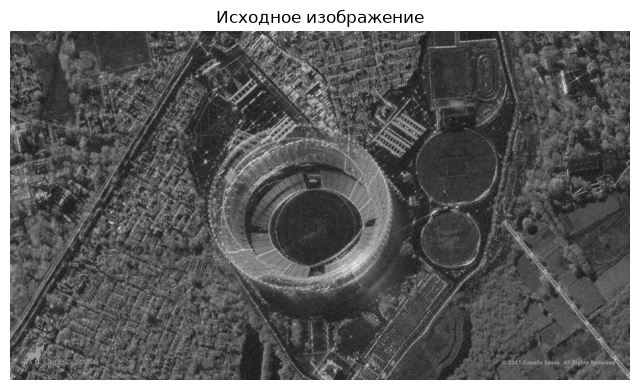

In [34]:
# Подготовка изображения
image = cv2.imread('sar_1.jpg', cv2.IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError('Файл sar_1.jpg не найден')

print('Размер изображения:', image.shape)
plt.figure(figsize=(8, 5))
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')
plt.show()

## 1. Добавление гауссова шума

Гауссов шум: sigma = 10
Гауссов шум: sigma = 25
Гауссов шум: sigma = 50


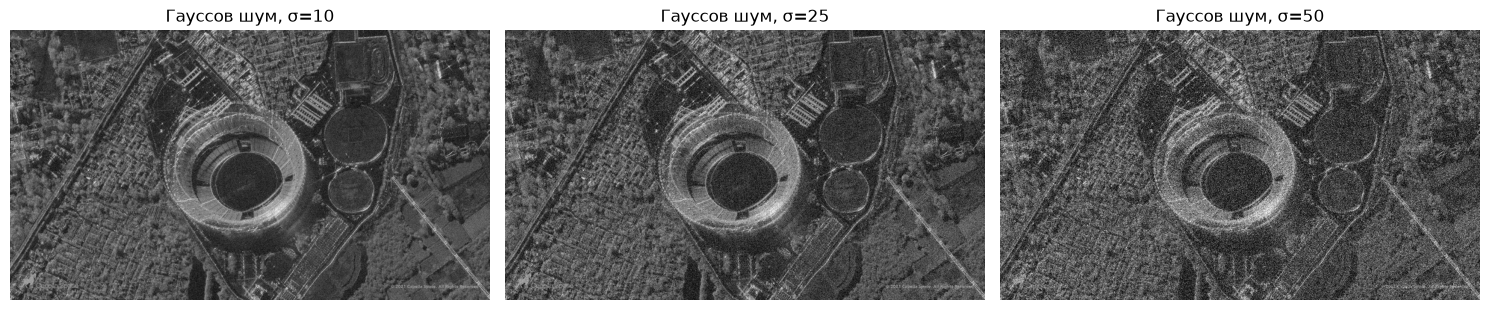

In [35]:
def add_gaussian_noise(img, mean=0, sigma=25):
    noise = np.random.normal(mean, sigma, img.shape)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

gaussian_sigmas = [10, 25, 50]
gaussian_noisy = {}

plt.figure(figsize=(15, 5))
for i, sigma in enumerate(gaussian_sigmas, 1):
    gaussian_noisy[sigma] = add_gaussian_noise(image, sigma=sigma)
    print(f'Гауссов шум: sigma = {sigma}')
    plt.subplot(1, 3, i)
    plt.imshow(gaussian_noisy[sigma], cmap='gray')
    plt.title(f'Гауссов шум, σ={sigma}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Добавление постоянного импульсного шума («соль и перец»)

Импульсный шум: amount = 0.01
Импульсный шум: amount = 0.03
Импульсный шум: amount = 0.05


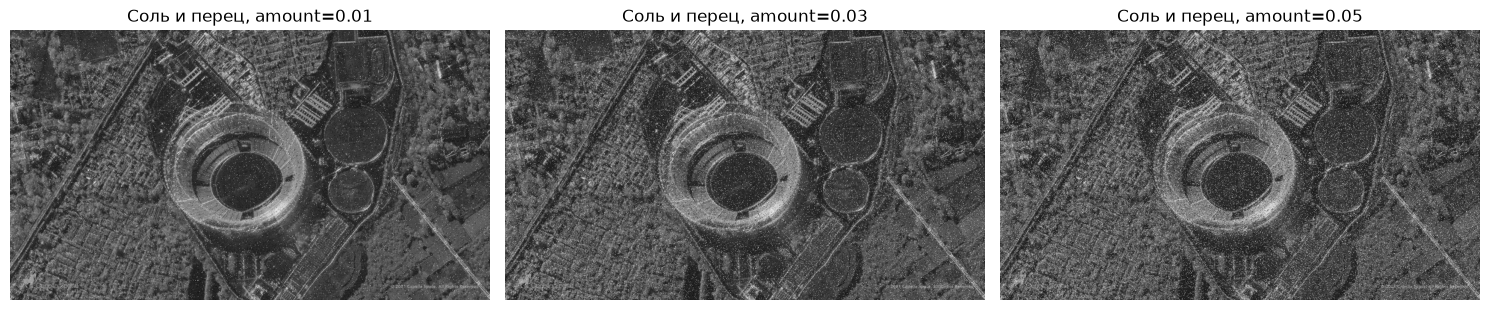

In [36]:
def add_salt_pepper_noise(img, amount=0.02):
    noisy = img.copy()
    h, w = noisy.shape
    n = int(h * w * amount)

    coords = np.random.choice(h * w, 2 * n, replace=False)
    salt_coords = np.unravel_index(coords[:n], (h, w))
    pepper_coords = np.unravel_index(coords[n:], (h, w))

    noisy[salt_coords] = 255
    noisy[pepper_coords] = 0
    return noisy

sp_amounts = [0.01, 0.03, 0.05]
sp_noisy = {}

plt.figure(figsize=(15, 5))
for i, amount in enumerate(sp_amounts, 1):
    sp_noisy[amount] = add_salt_pepper_noise(image, amount=amount)
    print(f'Импульсный шум: amount = {amount}')
    plt.subplot(1, 3, i)
    plt.imshow(sp_noisy[amount], cmap='gray')
    plt.title(f'Соль и перец, amount={amount}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Функция оценки качества

Для каждого результата рассчитываются MSE и SSIM относительно исходного изображения. Для MSE меньшее значение означает меньшее численное отличие, а SSIM ближе к 1 означает большее структурное сходство.

In [37]:
from skimage.metrics import mean_squared_error, structural_similarity

def metrics(original, result):
    mse = mean_squared_error(original, result)
    ssim = structural_similarity(original, result, data_range=255)
    return mse, ssim

def print_metrics(name, original, result):
    mse, ssim = metrics(original, result)
    print(f'{name}: MSE = {mse:.4f}, SSIM = {ssim:.6f}')
    return {'method': name, 'mse': mse, 'ssim': ssim, 'image': result}

## 4. Медианный фильтр с различными параметрами

In [38]:
median_ksizes = [3, 5, 7]

def test_median(noisy, prefix):
    results = []
    for k in median_ksizes:
        filtered = cv2.medianBlur(noisy, k)
        results.append(print_metrics(f'{prefix} — Median k={k}', image, filtered))
    return results

gauss_median_results = test_median(gaussian_noisy[25], 'Гауссов шум')
sp_median_results = test_median(sp_noisy[0.03], 'Импульсный шум')

Гауссов шум — Median k=3: MSE = 209.9153, SSIM = 0.637900
Гауссов шум — Median k=5: MSE = 240.7268, SSIM = 0.560893
Гауссов шум — Median k=7: MSE = 286.4433, SSIM = 0.481995
Импульсный шум — Median k=3: MSE = 101.0488, SSIM = 0.809827
Импульсный шум — Median k=5: MSE = 196.1381, SSIM = 0.631235
Импульсный шум — Median k=7: MSE = 261.2319, SSIM = 0.521332


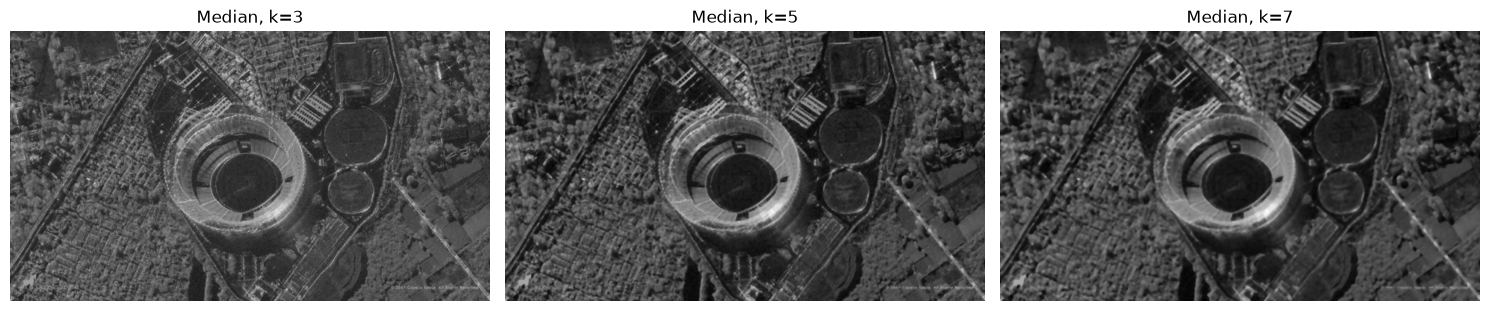

In [39]:
plt.figure(figsize=(15, 5))
for i, k in enumerate(median_ksizes, 1):
    result = cv2.medianBlur(sp_noisy[0.03], k)
    plt.subplot(1, 3, i)
    plt.imshow(result, cmap='gray')
    plt.title(f'Median, k={k}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Гауссов фильтр с различными параметрами

In [40]:
gaussian_ksizes = [3, 5, 7]
gaussian_sigmas = [0, 1, 2]

def test_gaussian(noisy, prefix):
    results = []
    for k in gaussian_ksizes:
        for sigma in gaussian_sigmas:
            filtered = cv2.GaussianBlur(noisy, (k, k), sigma)
            results.append(print_metrics(f'{prefix} — Gaussian k={k}, sigma={sigma}', image, filtered))
    return results

gauss_gaussian_results = test_gaussian(gaussian_noisy[25], 'Гауссов шум')
sp_gaussian_results = test_gaussian(sp_noisy[0.03], 'Импульсный шум')

Гауссов шум — Gaussian k=3, sigma=0: MSE = 149.6769, SSIM = 0.724993
Гауссов шум — Gaussian k=3, sigma=1: MSE = 150.5531, SSIM = 0.721491
Гауссов шум — Gaussian k=3, sigma=2: MSE = 162.3477, SSIM = 0.698763
Гауссов шум — Gaussian k=5, sigma=0: MSE = 156.3019, SSIM = 0.707093
Гауссов шум — Gaussian k=5, sigma=1: MSE = 151.7381, SSIM = 0.715736
Гауссов шум — Gaussian k=5, sigma=2: MSE = 198.7355, SSIM = 0.628677
Гауссов шум — Gaussian k=7, sigma=0: MSE = 188.6557, SSIM = 0.648476
Гауссов шум — Gaussian k=7, sigma=1: MSE = 152.7751, SSIM = 0.713677
Гауссов шум — Gaussian k=7, sigma=2: MSE = 224.4067, SSIM = 0.584032
Импульсный шум — Gaussian k=3, sigma=0: MSE = 245.0065, SSIM = 0.642457
Импульсный шум — Gaussian k=3, sigma=1: MSE = 237.4907, SSIM = 0.641909
Импульсный шум — Gaussian k=3, sigma=2: MSE = 241.2043, SSIM = 0.624161
Импульсный шум — Gaussian k=5, sigma=0: MSE = 215.2568, SSIM = 0.644087
Импульсный шум — Gaussian k=5, sigma=1: MSE = 215.4192, SSIM = 0.648818
Импульсный шум — Ga

## 6. Билатеральный фильтр с различными параметрами

In [41]:
bilateral_params = [
    (5, 25, 25),
    (9, 50, 50),
    (9, 75, 75),
    (15, 100, 100)
]

def test_bilateral(noisy, prefix):
    results = []
    for d, sigma_color, sigma_space in bilateral_params:
        filtered = cv2.bilateralFilter(noisy, d, sigma_color, sigma_space)
        name = f'{prefix} — Bilateral d={d}, σC={sigma_color}, σS={sigma_space}'
        results.append(print_metrics(name, image, filtered))
    return results

gauss_bilateral_results = test_bilateral(gaussian_noisy[25], 'Гауссов шум')
sp_bilateral_results = test_bilateral(sp_noisy[0.03], 'Импульсный шум')

Гауссов шум — Bilateral d=5, σC=25, σS=25: MSE = 301.4789, SSIM = 0.604345
Гауссов шум — Bilateral d=9, σC=50, σS=50: MSE = 178.5992, SSIM = 0.660816
Гауссов шум — Bilateral d=9, σC=75, σS=75: MSE = 201.4140, SSIM = 0.613530
Гауссов шум — Bilateral d=15, σC=100, σS=100: MSE = 308.7938, SSIM = 0.459658
Импульсный шум — Bilateral d=5, σC=25, σS=25: MSE = 1179.6996, SSIM = 0.364122
Импульсный шум — Bilateral d=9, σC=50, σS=50: MSE = 999.5361, SSIM = 0.324677
Импульсный шум — Bilateral d=9, σC=75, σS=75: MSE = 481.8661, SSIM = 0.411802
Импульсный шум — Bilateral d=15, σC=100, σS=100: MSE = 358.3479, SSIM = 0.386972


## 7. Фильтр нелокальных средних с различными параметрами

In [42]:
nlm_params = [
    (7, 21, 10),
    (7, 21, 20),
    (7, 21, 30),
    (7, 31, 20)
]

def test_nlm(noisy, prefix):
    results = []
    for template, search, h in nlm_params:
        filtered = cv2.fastNlMeansDenoising(
            noisy, None, h, template, search
        )
        name = f'{prefix} — NLM template={template}, search={search}, h={h}'
        results.append(print_metrics(name, image, filtered))
    return results

gauss_nlm_results = test_nlm(gaussian_noisy[25], 'Гауссов шум')
sp_nlm_results = test_nlm(sp_noisy[0.03], 'Импульсный шум')

Гауссов шум — NLM template=7, search=21, h=10: MSE = 608.1529, SSIM = 0.481855
Гауссов шум — NLM template=7, search=21, h=20: MSE = 180.8806, SSIM = 0.666621
Гауссов шум — NLM template=7, search=21, h=30: MSE = 259.4167, SSIM = 0.505535
Гауссов шум — NLM template=7, search=31, h=20: MSE = 177.8599, SSIM = 0.653175
Импульсный шум — NLM template=7, search=21, h=10: MSE = 1170.4235, SSIM = 0.422770
Импульсный шум — NLM template=7, search=21, h=20: MSE = 782.5337, SSIM = 0.459467
Импульсный шум — NLM template=7, search=21, h=30: MSE = 300.3375, SSIM = 0.486573
Импульсный шум — NLM template=7, search=31, h=20: MSE = 691.9468, SSIM = 0.468001


## 8. Сравнение результатов и определение лучшего фильтра

In [43]:
all_results_gauss = (
    gauss_median_results +
    gauss_gaussian_results +
    gauss_bilateral_results +
    gauss_nlm_results
)

all_results_sp = (
    sp_median_results +
    sp_gaussian_results +
    sp_bilateral_results +
    sp_nlm_results
)

def show_best(results, noise_name):
    best_mse = min(results, key=lambda x: x['mse'])
    best_ssim = max(results, key=lambda x: x['ssim'])

    print(f'\n=== {noise_name} ===')
    print('Лучший результат по MSE:')
    print(f"  {best_mse['method']}, MSE = {best_mse['mse']:.4f}, SSIM = {best_mse['ssim']:.6f}")
    print('Лучший результат по SSIM:')
    print(f"  {best_ssim['method']}, MSE = {best_ssim['mse']:.4f}, SSIM = {best_ssim['ssim']:.6f}")

    return best_mse, best_ssim

best_gauss = show_best(all_results_gauss, 'Гауссов шум, σ=25')
best_sp = show_best(all_results_sp, 'Импульсный шум, amount=0.03')


=== Гауссов шум, σ=25 ===
Лучший результат по MSE:
  Гауссов шум — Gaussian k=3, sigma=0, MSE = 149.6769, SSIM = 0.724993
Лучший результат по SSIM:
  Гауссов шум — Gaussian k=3, sigma=0, MSE = 149.6769, SSIM = 0.724993

=== Импульсный шум, amount=0.03 ===
Лучший результат по MSE:
  Импульсный шум — Median k=3, MSE = 101.0488, SSIM = 0.809827
Лучший результат по SSIM:
  Импульсный шум — Median k=3, MSE = 101.0488, SSIM = 0.809827


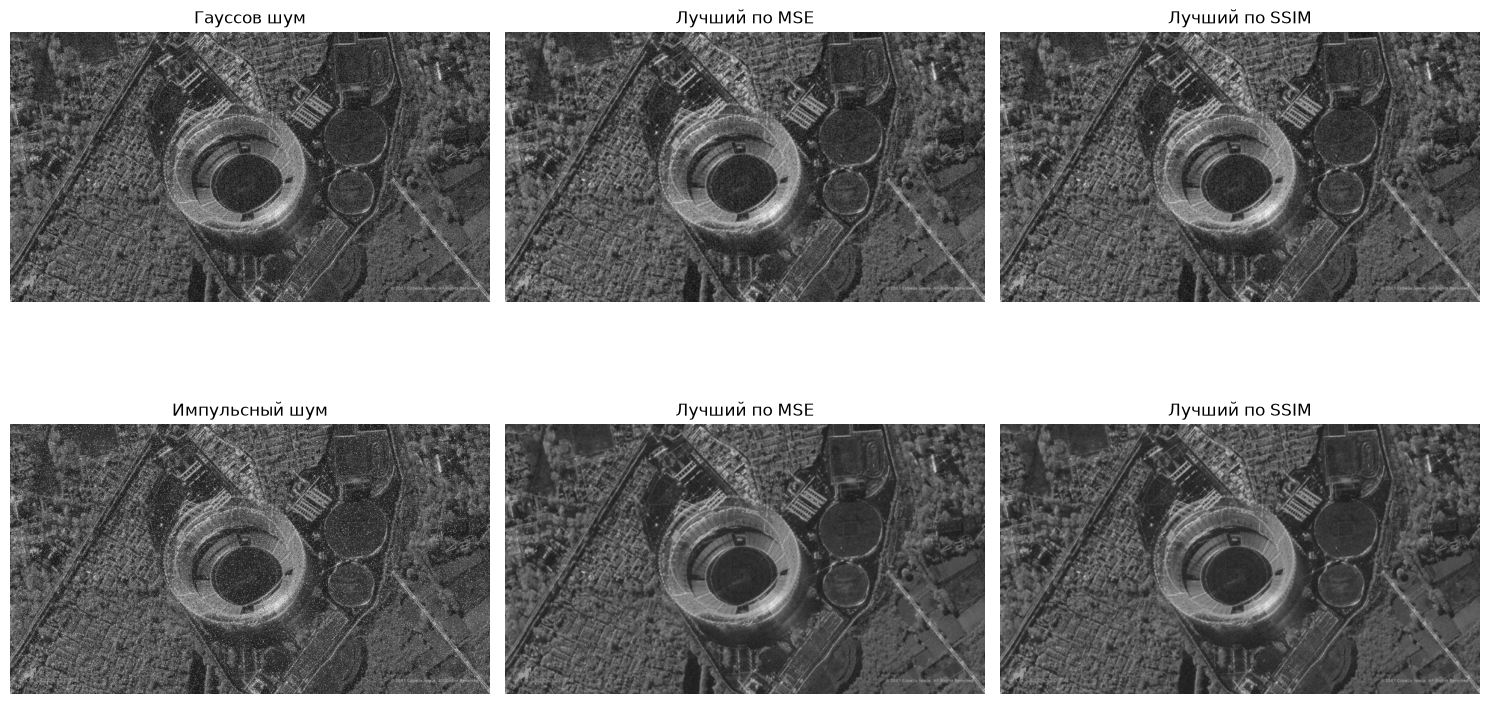

In [44]:
# Визуальное сравнение лучших результатов для каждого типа шума
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].imshow(gaussian_noisy[25], cmap='gray')
axes[0, 0].set_title('Гауссов шум')
axes[0, 1].imshow(best_gauss[0]['image'], cmap='gray')
axes[0, 1].set_title('Лучший по MSE')
axes[0, 2].imshow(best_gauss[1]['image'], cmap='gray')
axes[0, 2].set_title('Лучший по SSIM')

axes[1, 0].imshow(sp_noisy[0.03], cmap='gray')
axes[1, 0].set_title('Импульсный шум')
axes[1, 1].imshow(best_sp[0]['image'], cmap='gray')
axes[1, 1].set_title('Лучший по MSE')
axes[1, 2].imshow(best_sp[1]['image'], cmap='gray')
axes[1, 2].set_title('Лучший по SSIM')

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()